# 06 — LGD Model (Loss Given Default)

**Objective:** Predict the fraction of exposure lost upon default (`lgd`, bounded [0, 1]).

**Input:** `df_model_raw.csv` — full raw dataset (1,348,099 loans × 157 columns). We filter to defaulted loans, apply the preprocessing pipeline from notebook 02, and create the LGD target.

**Approach:**
1. Load raw data, filter to defaults, preprocess, create LGD target
2. Vintage-based split: 2007–2015 train, 2016–2017 test
3. Feature engineering (same pipeline as notebooks 02–03)
4. Benchmark: Linear Regression, Random Forest, XGBoost, LightGBM regressors
5. Tune LightGBM (best baseline) with Optuna (20 trials)
6. Evaluate: MAE, RMSE, R², WAPE

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
import json
import time
import os
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Load Data & Train/Test Split

In [ ]:
# Load raw data — need full features + leakage columns for LGD target
df = pd.read_csv('../data/df_model_raw.csv', low_memory=False)

# Parse issue date and create targets BEFORE dropping leakage columns
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d_parsed'].dt.year
df['issue_month'] = df['issue_d_parsed'].dt.month

# Filter to defaults only, exclude 2018 (right-censored)
df = df[(df['default'] == 1) & (df['issue_year'] <= 2017)].copy()

# EAD target (carried through for reference)
df['ead_pct'] = ((df['funded_amnt'] - df['total_rec_prncp']) / df['funded_amnt']).clip(0, 1)
# LGD target: 1 - recovery rate
df['lgd'] = (1 - (df['recoveries'] / df['funded_amnt']).clip(0, 1)).clip(0, 1)

# --- Preprocessing pipeline (mirrors notebook 02) ---
drop_cols = [
    # Leakage (post-outcome)
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'disbursement_method',
    # ID / text / URL
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code',
    # Redundant
    'funded_amnt', 'funded_amnt_inv', 'grade', 'loan_status',
    # EDA temp
    'fico_avg', 'fico_bin', 'issue_date',
]
single_val = [c for c in df.columns if df[c].nunique() <= 1]
high_miss = df.columns[df.isnull().mean() > 0.5].tolist()
drop_cols = drop_cols + single_val + high_miss

keep = {'default', 'ead_pct', 'lgd', 'issue_year', 'issue_month'}
drop_cols = list(set(c for c in drop_cols if c in df.columns and c not in keep))
df.drop(columns=drop_cols, inplace=True)

# Parse term
df['term'] = df['term'].str.strip().str.replace(' months', '', regex=False).astype(int)

# Parse emp_length
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length'] = df['emp_length'].map(emp_map)

# Credit history length
ecl = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d_parsed'].dt.year - ecl.dt.year) * 12 +
    (df['issue_d_parsed'].dt.month - ecl.dt.month)
)
df.drop(columns=['earliest_cr_line', 'issue_d', 'issue_d_parsed'], inplace=True, errors='ignore')

# Home ownership: merge rare categories
df['home_ownership'] = df['home_ownership'].replace({'NONE': 'OTHER', 'ANY': 'OTHER'})

# Application type — drop
df.drop(columns=['application_type'], inplace=True, errors='ignore')

# Initial list status → binary
df['initial_list_status'] = (df['initial_list_status'] == 'f').astype(int)

# FICO score
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# Median imputation for all numeric missing values
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any() and col not in keep:
        df[col].fillna(df[col].median(), inplace=True)

# Outlier winsorization at 99.5th percentile
for col in ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc']:
    if col in df.columns:
        df[col] = df[col].clip(upper=df[col].quantile(0.995))
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].clip(upper=100)
if 'dti' in df.columns:
    df['dti'] = df['dti'].clip(lower=0)

print(f"Defaulted loans: {df.shape}")
print(f"\nLGD stats:")
print(df['lgd'].describe())
print(f"\nVintage distribution:")
print(df['issue_year'].value_counts().sort_index())

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")

Defaulted loans: (260486, 68)

LGD stats:
count    260486.000000
mean          0.923239
std           0.095304
min           0.000000
25%           0.887351
50%           0.935588
75%           1.000000
max           1.000000
Name: lgd, dtype: float64

Vintage distribution:
issue_year
2007      158
2008      496
2009      723
2010     1757
2011     3297
2012     8644
2013    21024
2014    41162
2015    75804
2016    68252
2017    39169
Name: count, dtype: int64

Categorical columns (5): ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


In [22]:
# Vintage-based split
train = df[df['issue_year'] <= 2015].copy()
test = df[df['issue_year'].between(2016, 2017)].copy()

print(f"Train (2007-2015): {train.shape}  |  LGD mean: {train['lgd'].mean():.4f}")
print(f"Test  (2016-2017): {test.shape}  |  LGD mean: {test['lgd'].mean():.4f}")

Train (2007-2015): (153065, 68)  |  LGD mean: 0.9210
Test  (2016-2017): (107421, 68)  |  LGD mean: 0.9265


## 2. Feature Engineering

Same pipeline as notebooks 02–03: ordinal encoding for sub_grade, one-hot for home/verif/purpose, target encoding for state (using mean LGD instead of default rate). Financial ratios added from raw credit bureau fields.

In [23]:
# --- Ordinal encoding: sub_grade ---
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f'{g}{n}' for g in grades for n in range(1, 6)]
sub_grade_map = {sg: i for i, sg in enumerate(sub_grades)}

for d in [train, test]:
    d['sub_grade_encoded'] = d['sub_grade'].map(sub_grade_map)

# --- One-hot encoding ---
for col, prefix in [('home_ownership', 'home'),
                     ('verification_status', 'verif'),
                     ('purpose', 'purpose')]:
    train = pd.get_dummies(train, columns=[col], prefix=prefix, drop_first=True)
    test = pd.get_dummies(test, columns=[col], prefix=prefix, drop_first=True)

# Align columns
for col in train.columns:
    if col not in test.columns:
        test[col] = 0
for col in test.columns:
    if col not in train.columns:
        train[col] = 0

# --- State target encoding (using LGD as target) ---
global_lgd = train['lgd'].mean()
smoothing = 100
state_stats = train.groupby('addr_state')['lgd'].agg(['mean', 'count'])
state_stats['smoothed'] = (
    (state_stats['count'] * state_stats['mean'] + smoothing * global_lgd) /
    (state_stats['count'] + smoothing)
)
state_map = state_stats['smoothed'].to_dict()

train['state_lgd_rate'] = train['addr_state'].map(state_map)
test['state_lgd_rate'] = test['addr_state'].map(state_map)
test['state_lgd_rate'].fillna(global_lgd, inplace=True)

# Drop original categoricals
train.drop(columns=['sub_grade', 'addr_state'], inplace=True, errors='ignore')
test.drop(columns=['sub_grade', 'addr_state'], inplace=True, errors='ignore')

print(f"After encoding — Train: {train.shape}, Test: {test.shape}")

After encoding — Train: (153065, 83), Test: (107421, 83)


In [24]:
# --- Financial ratios ---
def create_features(d):
    d['loan_to_income'] = d['loan_amnt'] / (d['annual_inc'] + 1)
    d['installment_to_income'] = d['installment'] / (d['annual_inc'] / 12 + 1)
    d['revol_bal_to_income'] = d['revol_bal'] / (d['annual_inc'] + 1)
    d['available_credit'] = d['total_rev_hi_lim'] - d['revol_bal']
    d['available_credit_pct'] = d['available_credit'] / (d['total_rev_hi_lim'] + 1)
    d['active_ratio'] = d['open_acc'] / (d['total_acc'] + 1)
    d['delinq_per_account'] = d['delinq_2yrs'] / (d['total_acc'] + 1)
    d['pub_rec_per_account'] = d['pub_rec'] / (d['total_acc'] + 1)
    d['installment_pct_of_loan'] = d['installment'] / (d['loan_amnt'] + 1)
    d['accounts_per_year'] = d['total_acc'] / (d['credit_history_months'] / 12 + 1)
    return d

train = create_features(train)
test = create_features(test)

# Handle inf/extreme
for d in [train, test]:
    d.replace([np.inf, -np.inf], np.nan, inplace=True)

ratio_cols = ['loan_to_income', 'installment_to_income', 'revol_bal_to_income',
              'available_credit', 'available_credit_pct', 'active_ratio',
              'delinq_per_account', 'pub_rec_per_account',
              'installment_pct_of_loan', 'accounts_per_year']

for col in ratio_cols:
    if train[col].isnull().any():
        med = train[col].median()
        train[col].fillna(med, inplace=True)
        test[col].fillna(med, inplace=True)
    upper = train[col].quantile(0.995)
    train[col] = train[col].clip(upper=upper)
    test[col] = test[col].clip(upper=upper)

# --- Prepare features and target ---
exclude_cols = {'default', 'ead_pct', 'lgd'}
feature_cols = sorted([c for c in train.columns if c not in exclude_cols])

# Drop constant columns
constant = [c for c in feature_cols if train[c].nunique() <= 1]
if constant:
    feature_cols = [c for c in feature_cols if c not in constant]
    print(f"Dropped {len(constant)} constant columns")

y_train_full = train['lgd']
y_test = test['lgd']
X_train_full = train[feature_cols]
X_test = test[feature_cols]

print(f"Features: {len(feature_cols)}")
print(f"X_train: {X_train_full.shape}  |  y_train mean: {y_train_full.mean():.4f}")
print(f"X_test:  {X_test.shape}  |  y_test mean:  {y_test.mean():.4f}")
print(f"Missing — train: {X_train_full.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")

Features: 90
X_train: (153065, 90)  |  y_train mean: 0.9210
X_test:  (107421, 90)  |  y_test mean:  0.9265
Missing — train: 0, test: 0


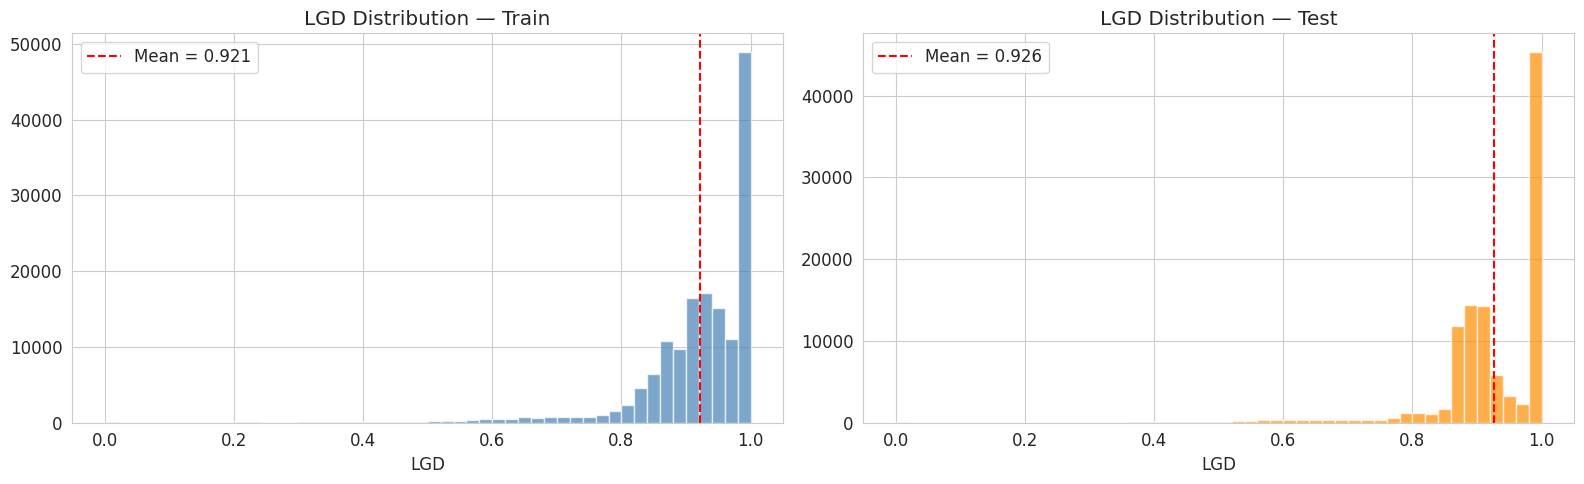


LGD = 1.0 (zero recovery): 23.1% of train
LGD > 0.9:                  71.1% of train
LGD < 0.5:                  0.7% of train


In [25]:
# LGD distribution — train vs test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(y_train_full, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].axvline(y_train_full.mean(), color='red', linestyle='--',
                label=f'Mean = {y_train_full.mean():.3f}')
axes[0].set_title('LGD Distribution — Train')
axes[0].set_xlabel('LGD')
axes[0].legend()

axes[1].hist(y_test, bins=50, alpha=0.7, color='darkorange', edgecolor='white')
axes[1].axvline(y_test.mean(), color='red', linestyle='--',
                label=f'Mean = {y_test.mean():.3f}')
axes[1].set_title('LGD Distribution — Test')
axes[1].set_xlabel('LGD')
axes[1].legend()

plt.tight_layout()
plt.show()

# LGD is heavily skewed toward 1.0 — most defaulted loans have very low recovery
print(f"\nLGD = 1.0 (zero recovery): {(y_train_full == 1.0).mean():.1%} of train")
print(f"LGD > 0.9:                  {(y_train_full > 0.9).mean():.1%} of train")
print(f"LGD < 0.5:                  {(y_train_full < 0.5).mean():.1%} of train")

## 3. Baseline Regression Benchmarking

LGD is heavily right-skewed (concentrated near 1.0), making this a challenging regression target. Tree-based models typically handle this better than linear approaches.

In [26]:
# Validation split for early stopping
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

results = {}

def evaluate(name, y_true, y_pred, elapsed, extra=None):
    y_pred_clip = np.clip(y_pred, 0, 1)
    wape = np.sum(np.abs(y_true - y_pred_clip)) / np.sum(np.abs(y_true)) if np.sum(np.abs(y_true)) > 0 else 0
    r = {
        'MAE': mean_absolute_error(y_true, y_pred_clip),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred_clip)),
        'R2': r2_score(y_true, y_pred_clip),
        'WAPE': wape,
        'time': elapsed,
        'preds': y_pred_clip,
    }
    if extra:
        r.update(extra)
    results[name] = r
    print(f"     MAE={r['MAE']:.4f}  RMSE={r['RMSE']:.4f}  R²={r['R2']:.4f}  WAPE={r['WAPE']:.4f}  ({elapsed:.1f}s)")

# --- Linear Regression ---
print("1/4  Linear Regression...")
t0 = time.time()
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)
evaluate('Linear Reg.', y_test, lr.predict(X_test), time.time() - t0)

# --- Random Forest ---
print("2/4  Random Forest...")
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test), time.time() - t0)

# --- XGBoost ---
print("3/4  XGBoost...")
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=50, eval_metric='mae',
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
evaluate('XGBoost', y_test, xgb_model.predict(X_test), time.time() - t0,
         {'best_iter': xgb_model.best_iteration})

# --- LightGBM ---
print("4/4  LightGBM...")
t0 = time.time()
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
evaluate('LightGBM', y_test, lgb_model.predict(X_test), time.time() - t0,
         {'best_iter': lgb_model.best_iteration_})

1/4  Linear Regression...
     MAE=0.0649  RMSE=0.0936  R²=-0.0197  WAPE=0.0701  (1.2s)
2/4  Random Forest...
     MAE=0.0642  RMSE=0.0926  R²=0.0030  WAPE=0.0693  (672.3s)
3/4  XGBoost...
     MAE=0.0643  RMSE=0.0925  R²=0.0036  WAPE=0.0694  (4.1s)
4/4  LightGBM...
     MAE=0.0642  RMSE=0.0925  R²=0.0053  WAPE=0.0693  (4.1s)


## 4. Benchmark Comparison

                 MAE   RMSE      R²   WAPE  Time (s)
LightGBM      0.0642 0.0925  0.0053 0.0693    4.0535
Random Forest 0.0642 0.0926  0.0030 0.0693  672.3251
XGBoost       0.0643 0.0925  0.0036 0.0694    4.1195
Linear Reg.   0.0649 0.0936 -0.0197 0.0701    1.1981

Best baseline: LightGBM (MAE = 0.0642)

✓  LightGBM has positive R² — proceed with Optuna tuning.


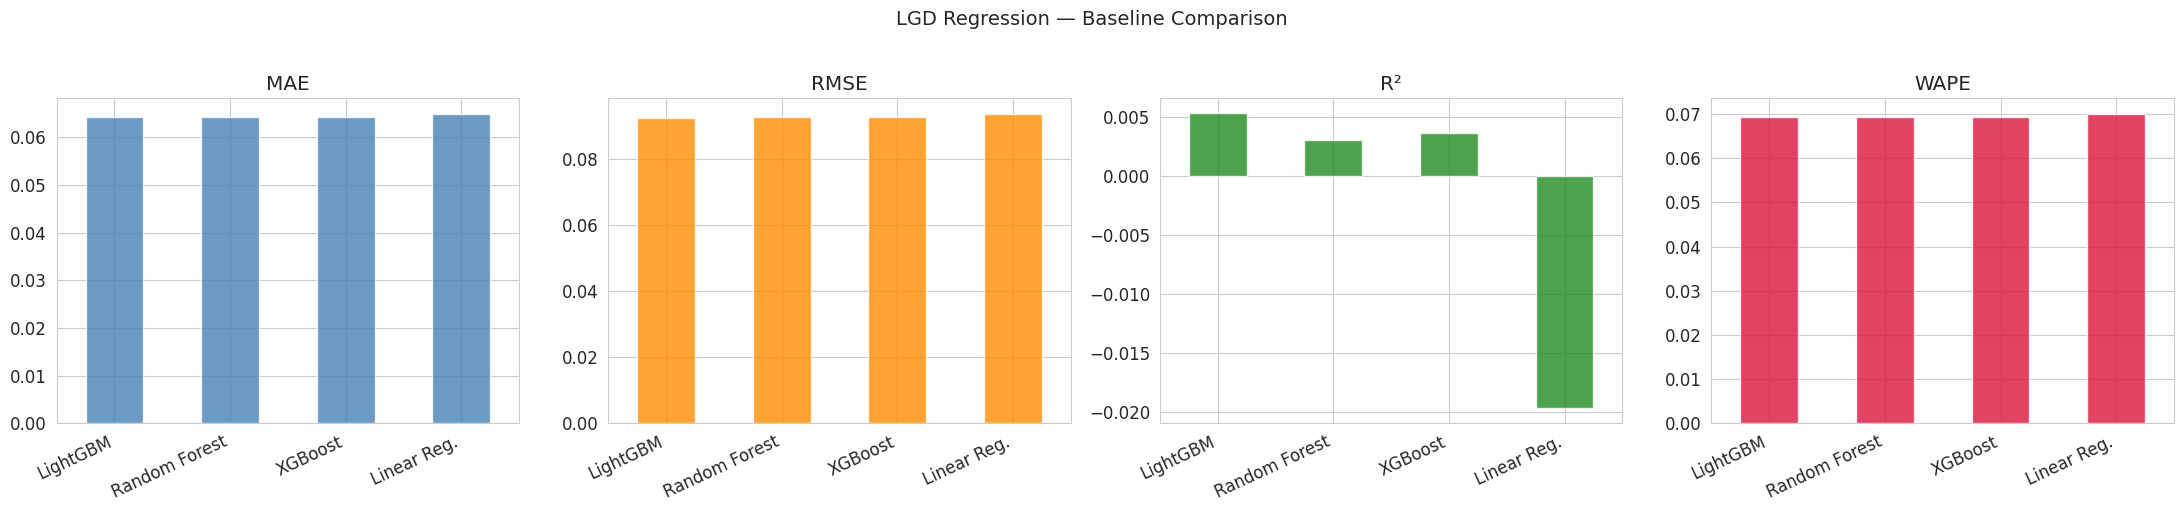

In [27]:
comp_df = pd.DataFrame({
    name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2'], 'WAPE': r['WAPE'], 'Time (s)': r['time']}
    for name, r in results.items()
}).T.sort_values('MAE')

print(comp_df.to_string(float_format='{:.4f}'.format))

best_name = comp_df['MAE'].idxmin()
print(f"\nBest baseline: {best_name} (MAE = {comp_df.loc[best_name, 'MAE']:.4f})")

# Flag if all models have negative R²
if (comp_df['R²'] < 0).all():
    print("\n⚠️  All models have NEGATIVE R² — regression cannot beat predicting the mean.")
    print("    Consider using mean LGD (like notebook 05 EAD) instead of tuning.")
else:
    print(f"\n✓  {best_name} has positive R² — proceed with Optuna tuning.")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'R²', 'WAPE'],
                              ['steelblue', 'darkorange', 'forestgreen', 'crimson']):
    comp_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.8)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('LGD Regression — Baseline Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning — Optuna

Tuning the best-performing regressor with 20 Bayesian optimization trials. Objective: minimize MAE on validation set.

In [30]:
# LightGBM selected: lowest MAE (0.0642), highest R² (0.0053), fastest tree model (4.1s vs 672s RF)
tune_xgb = False
print("Tuning: LightGBM (lowest MAE, highest R², fastest tree model)")

def objective(trial):
    if tune_xgb:
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = xgb.XGBRegressor(
            n_estimators=2000, eval_metric='mae',
            early_stopping_rounds=50,
            random_state=42, n_jobs=-1, verbosity=0, **params
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        trial.set_user_attr('best_iteration', model.best_iteration)
    else:
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = lgb.LGBMRegressor(
            n_estimators=2000,
            random_state=42, n_jobs=-1, verbose=-1, **params
        )
        model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        )
        trial.set_user_attr('best_iteration', model.best_iteration_)

    preds = np.clip(model.predict(X_val), 0, 1)
    return mean_absolute_error(y_val, preds)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
print("Running 20 Optuna trials...")
t0 = time.time()
study.optimize(objective, n_trials=20, show_progress_bar=True)
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Best Val MAE: {study.best_value:.4f}")
print(f"Best iteration: {study.best_trial.user_attrs['best_iteration']}")

Tuning: LightGBM (lowest MAE, highest R², fastest tree model)
Running 20 Optuna trials...


  0%|          | 0/20 [00:00<?, ?it/s]


Done in 143s
Best Val MAE: 0.0624
Best iteration: 164


Best hyperparameters:
  learning_rate             0.066414
  num_leaves                74
  max_depth                 5
  min_child_samples         92
  subsample                 0.701292
  colsample_bytree          0.672847
  reg_alpha                 1.610675
  reg_lambda                0.000003


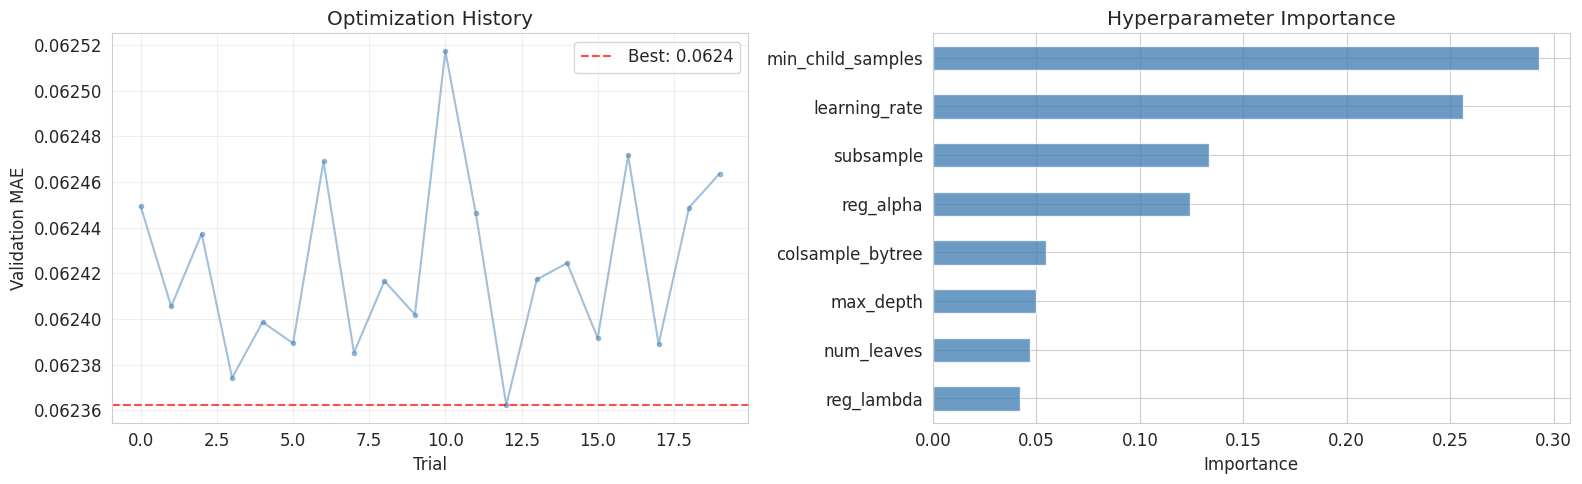

In [31]:
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<25} {v:.6f}" if isinstance(v, float) else f"  {k:<25} {v}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

values = [t.value for t in study.trials]
axes[0].plot(values, 'o-', markersize=3, alpha=0.5, color='steelblue')
axes[0].axhline(y=study.best_value, color='red', linestyle='--', alpha=0.7,
                label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation MAE')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

try:
    importances = optuna.importance.get_param_importances(study)
    pd.Series(importances).plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
    axes[1].set_title('Hyperparameter Importance')
    axes[1].set_xlabel('Importance')
    axes[1].invert_yaxis()
except Exception:
    axes[1].text(0.5, 0.5, 'Could not compute\nimportances',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 6. Final Model Training

In [32]:
best_iter = study.best_trial.user_attrs['best_iteration']
best_params = study.best_params
final_n = int(best_iter * 1.1)

if tune_xgb:
    final_model = xgb.XGBRegressor(
        n_estimators=final_n, eval_metric='mae',
        random_state=42, n_jobs=-1, verbosity=0, **best_params
    )
    model_name = 'XGBoost'
else:
    final_model = lgb.LGBMRegressor(
        n_estimators=final_n,
        random_state=42, n_jobs=-1, verbose=-1, **best_params
    )
    model_name = 'LightGBM'

final_model.fit(X_train_full, y_train_full)

y_pred = np.clip(final_model.predict(X_test), 0, 1)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))

print(f"Final LGD Model ({model_name}) — Test Set:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")
print(f"  WAPE: {test_wape:.4f}")
print(f"  Iterations: {final_n}")

Final LGD Model (LightGBM) — Test Set:
  MAE:  0.0641
  RMSE: 0.0923
  R²:   0.0095
  WAPE: 0.0692
  Iterations: 180


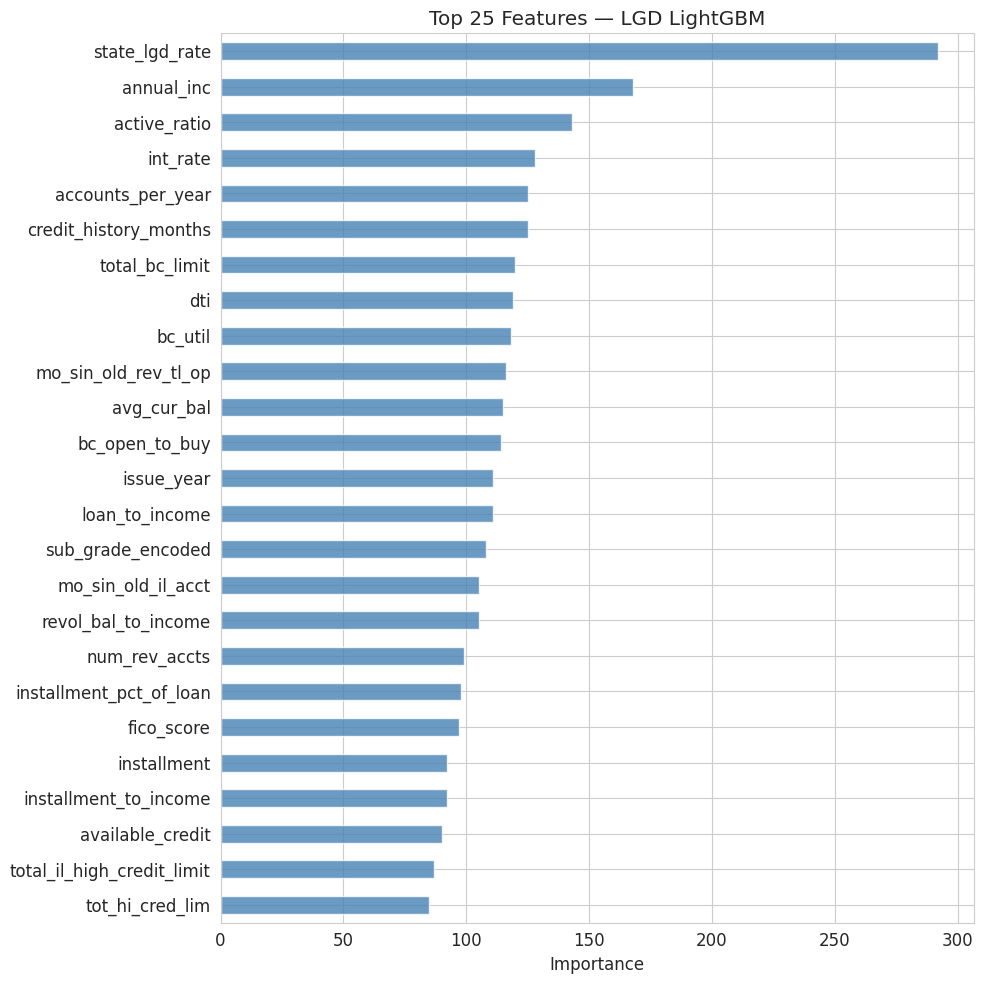


Top 10 features:
   1. state_lgd_rate                      292.0000
   2. annual_inc                          168.0000
   3. active_ratio                        143.0000
   4. int_rate                            128.0000
   5. accounts_per_year                   125.0000
   6. credit_history_months               125.0000
   7. total_bc_limit                      120.0000
   8. dti                                 119.0000
   9. bc_util                             118.0000
  10. mo_sin_old_rev_tl_op                116.0000


In [33]:
# Feature importance
imp = pd.Series(final_model.feature_importances_, index=feature_cols)
imp = imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
imp.head(25).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title(f'Top 25 Features — LGD {model_name}')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i, (f, v) in enumerate(imp.head(10).items()):
    print(f"  {i+1:>2}. {f:<35} {v:.4f}")

## 7. Model Evaluation

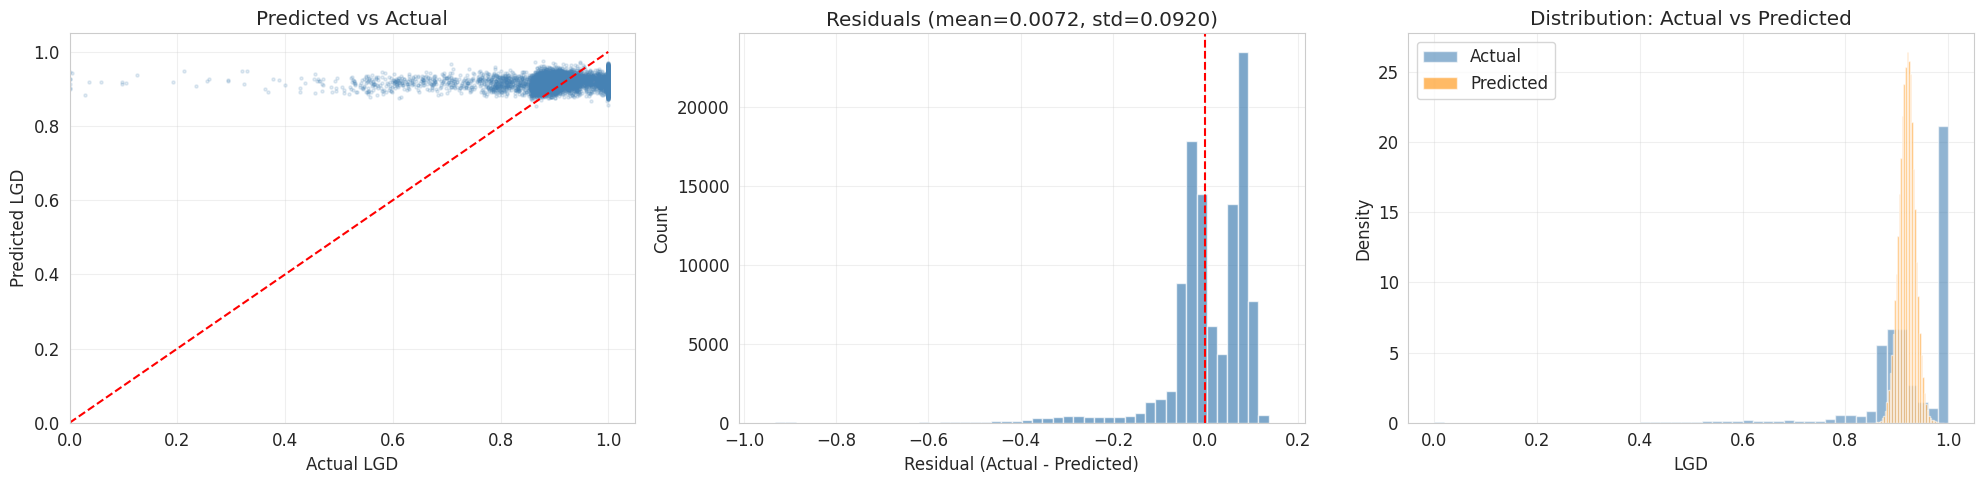

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Predicted vs Actual scatter
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(10000, len(y_test)), replace=False)
axes[0].scatter(y_test.values[sample_idx], y_pred[sample_idx],
                alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1.5)
axes[0].set_xlabel('Actual LGD')
axes[0].set_ylabel('Predicted LGD')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlim(0, 1.05)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Residual distribution
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals (mean={residuals.mean():.4f}, std={residuals.std():.4f})')
axes[1].grid(True, alpha=0.3)

# Prediction distribution vs actual
axes[2].hist(y_test, bins=50, alpha=0.6, color='steelblue', label='Actual', density=True)
axes[2].hist(y_pred, bins=50, alpha=0.6, color='darkorange', label='Predicted', density=True)
axes[2].set_xlabel('LGD')
axes[2].set_ylabel('Density')
axes[2].set_title('Distribution: Actual vs Predicted')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Decile Analysis (1 = lowest LGD, 10 = highest LGD):
        count  actual_mean  predicted_mean  actual_std
decile                                                
1       10743       0.9051          0.8914      0.1094
2       10742       0.9143          0.9030      0.1008
3       10742       0.9189          0.9090      0.0976
4       10742       0.9226          0.9136      0.0935
5       10742       0.9241          0.9177      0.0912
6       10742       0.9280          0.9215      0.0917
7       10742       0.9300          0.9254      0.0873
8       10742       0.9345          0.9296      0.0868
9       10742       0.9385          0.9352      0.0812
10      10742       0.9488          0.9464      0.0755


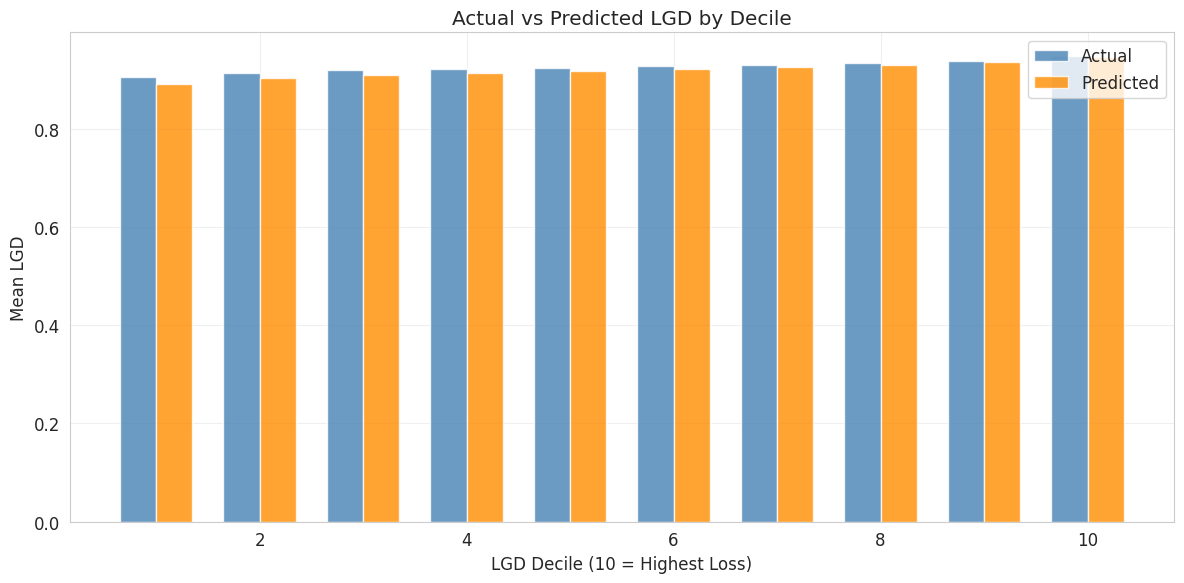

In [35]:
# Decile analysis — predicted LGD vs actual
test_res = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})
test_res['decile'] = pd.qcut(
    test_res['predicted'], q=10, labels=False, duplicates='drop'
) + 1

decile_df = test_res.groupby('decile').agg(
    count=('actual', 'count'),
    actual_mean=('actual', 'mean'),
    predicted_mean=('predicted', 'mean'),
    actual_std=('actual', 'std'),
).sort_index()

print("Decile Analysis (1 = lowest LGD, 10 = highest LGD):")
print(decile_df.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(12, 6))
x = decile_df.index
width = 0.35
ax.bar(x - width/2, decile_df['actual_mean'], width,
       label='Actual', color='steelblue', alpha=0.8)
ax.bar(x + width/2, decile_df['predicted_mean'], width,
       label='Predicted', color='darkorange', alpha=0.8)
ax.set_xlabel('LGD Decile (10 = Highest Loss)')
ax.set_ylabel('Mean LGD')
ax.set_title('Actual vs Predicted LGD by Decile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Model & Artifacts

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(final_model, '../models/lgd_model.joblib')
pd.Series(feature_cols).to_csv('../models/lgd_feature_names.csv',
                               index=False, header=['feature'])

metadata = {
    'model': model_name,
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'test_r2': float(test_r2),
    'test_wape': float(np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))),
    'n_features': len(feature_cols),
    'n_estimators': final_n,
    'best_params': best_params,
}
with open('../models/lgd_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:")
print(f"  ../models/lgd_model.joblib")
print(f"  ../models/lgd_feature_names.csv ({len(feature_cols)} features)")
print(f"  ../models/lgd_metadata.json")

## 9. LGD Model Summary

**Data:** 260,486 defaulted loans → train (2007–2015) / test (2016–2017)

**Target:** LGD ∈ [0, 1] — heavily skewed toward 1.0 (low recovery on unsecured consumer loans)

**Benchmark Results:**

| Model | MAE | RMSE | R² | WAPE |
|---|---|---|---|---|
| LightGBM | 0.0642 | 0.0925 | 0.0053 | 0.0693 |
| Random Forest | 0.0642 | 0.0926 | 0.0030 | 0.0693 |
| XGBoost | 0.0643 | 0.0925 | 0.0036 | 0.0694 |
| Linear Reg. | 0.0649 | 0.0936 | -0.0197 | 0.0701 |

R² is near zero across all models — origination features explain very little LGD variance. LGD on unsecured consumer loans is dominated by the recovery process (collections, charge-off timing), not borrower characteristics at origination.

**Tuning:** 20 Optuna trials on LightGBM (best baseline), minimizing MAE

**Final Model Metrics (Test Set):**

| Metric | Value |
|---|---|
| MAE | 0.0641 |
| RMSE | 0.0923 |
| R² | 0.0095 |
| WAPE | 0.0692 |

Tuning nearly doubled R² (0.0053 → 0.0095), but it's still low in absolute terms — expected, since LGD on unsecured loans is driven by post-default collection dynamics, not origination features. The model is directionally useful for risk segmentation but should not be treated as highly predictive at the loan level.

**Next Steps → Notebook 07 (Expected Loss):**
- Combine PD, EAD, LGD models: EL = PD × EAD × LGD
- Portfolio-level expected loss analysis
- Risk segmentation